## Importing the Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## Loading the Dataset

In [ ]:
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Data Preprocessing

In [ ]:
df = df.dropna()

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Select Relevant Features

In [ ]:
print("Selected Features: Annual Income and Spending Score")
print(X.head())

Selected Features: Annual Income and Spending Score
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


## Elbow Method to Determine Optimal K

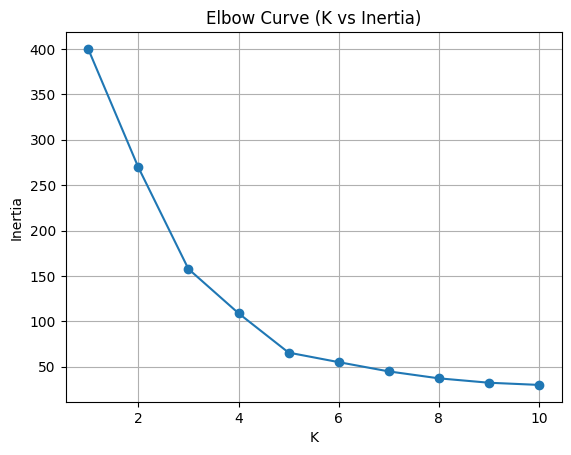

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Curve (K vs Inertia)')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


## Apply K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)


## Assign Cluster Labels

In [ ]:
df['Cluster'] = labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Visualize Clusters and Centroids

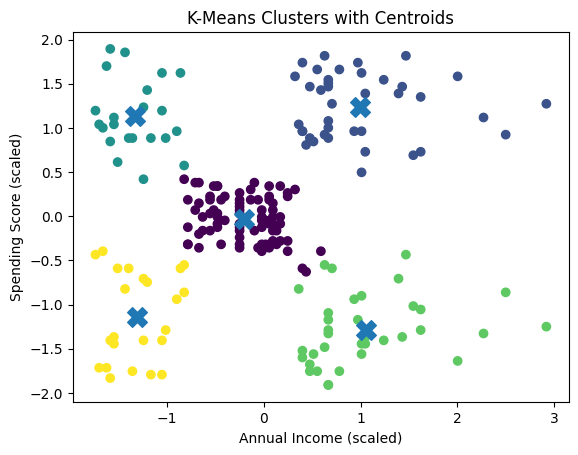

In [ ]:
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200)
plt.title('K-Means Clusters with Centroids')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()


## Interpret Cluster Characteristics

In [ ]:
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


## Evaluation Metrics

In [ ]:
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, labels))

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


### Effect of Different K Values

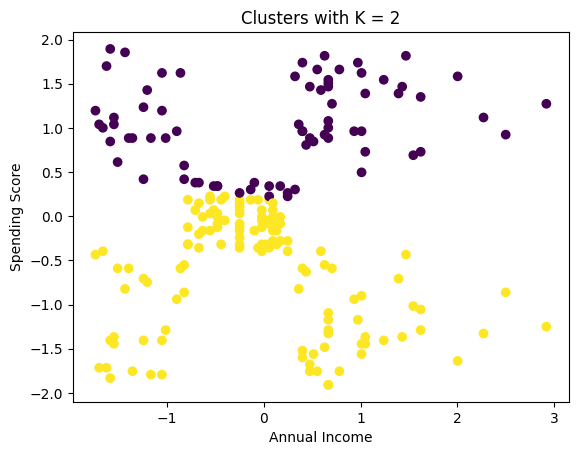

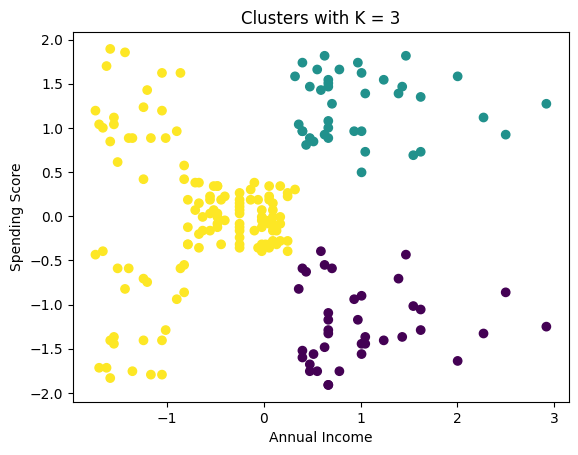

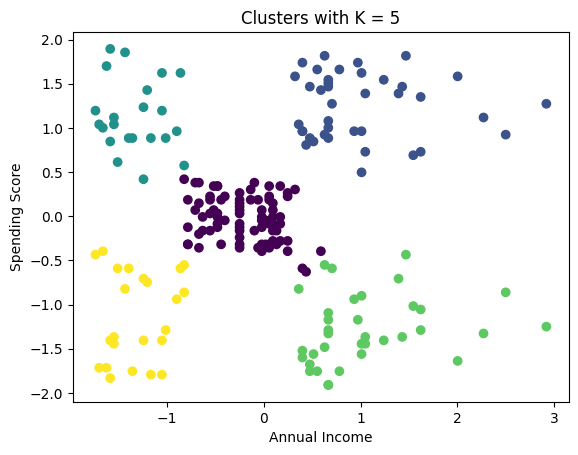

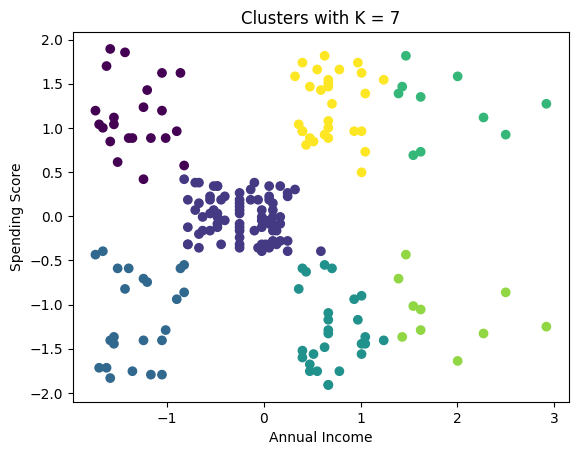

In [ ]:
for k in [2, 3, 5, 7]:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)

    plt.figure()
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_temp)
    plt.title(f'Clusters with K = {k}')
    plt.xlabel('Annual Income')
    plt.ylabel('Spending Score')
    plt.show()


### Sensitivity to Initialization

In [ ]:
kmeans_alt = KMeans(n_clusters=5, random_state=0, n_init=10)
labels_alt = kmeans_alt.fit_predict(X_scaled)

print("Silhouette (random_state=42):", silhouette_score(X_scaled, labels))
print("Silhouette (random_state=0):", silhouette_score(X_scaled, labels_alt))


Silhouette (random_state=42): 0.5546571631111091
Silhouette (random_state=0): 0.5546571631111091
